In [1]:
# Imports
from scipy.io import loadmat
import pandas as pd
import numpy as np
import plotly.express as px
import torch.nn as nn
import torch
import itertools
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

In [2]:
data = loadmat('Xtrain.mat')

In [3]:
def data_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df/255
    return normalized
    
def slices(s: pd.Series, slice_length) -> tuple[pd.Series, pd.Series]:
    slices = [window for window in s.rolling(window=slice_length+1)]
    res = [(slc.iloc[:-1], slc.iloc[-1]) for slc in slices[slice_length:]]
    return res


In [4]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True # needed because we have (batch_size, seq_len, 1). So batch size is given first
        )
        
        self.fc = nn.Linear(hidden_size, 1) # Connects final layer to output

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # pass through model
        out, _ = self.lstm(x)

        # out contains hidden states for all timesteps:
        # shape: (batch_size, seq_len, hidden_size)
        
        # we only care about last timestep.
        out = out[:, -1, :] #takes last timestep
        out = self.fc(out) # gets prediction
        
        return out

In [17]:
window_size = 16
hidden_size = 32
num_layers = 2
epochs = 500
learning_rate = 1e-3

# create data
series_full = pd.Series(data['Xtrain'].flatten())
series_full = data_cleaning(series_full).values

# recreate dataset with current chosen window
df = pd.Series(data['Xtrain'].flatten())
df = data_cleaning(df)

X, Y = zip(*slices(df, window_size))

X = np.array(X).reshape(-1, window_size, 1)
Y = np.array(Y).reshape(-1, 1)

split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y[:split], Y[split:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

def train_model(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = LSTMModel(hidden_size=hidden_size, num_layers=num_layers)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )

    dataset = TensorDataset(X_train, Y_train)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for epoch in range(epochs):
        model.train()
        train_loss_epoch = 0.0

        for X_batch, Y_batch in loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, Y_batch)
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item()

        train_loss_epoch /= len(loader)

        # validation loss (needed for scheduler)
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, Y_val).item()

        scheduler.step(val_loss)

    return model

In [18]:
n_models = 20

models = []

for i in range(n_models):
    print(f"Training model {i+1}/{n_models}")
    models.append(train_model(seed=23 + i))

Training model 1/20
Training model 2/20
Training model 3/20
Training model 4/20
Training model 5/20
Training model 6/20
Training model 7/20
Training model 8/20
Training model 9/20
Training model 10/20
Training model 11/20
Training model 12/20
Training model 13/20
Training model 14/20
Training model 15/20
Training model 16/20
Training model 17/20
Training model 18/20
Training model 19/20
Training model 20/20


In [19]:
def ensemble_recursive_predict(models, start_tensor, steps):

    window = start_tensor.clone().unsqueeze(0)  # (1, window, 1)
    preds = []

    for _ in range(steps):
        step_preds = []

        for model in models:
            model.eval()
            with torch.no_grad():
                pred = model(window)   # (1, 1)
                step_preds.append(pred.item())

        avg_pred = np.mean(step_preds)
        preds.append(avg_pred)

        # update window
        new_point = torch.tensor([[[avg_pred]]], dtype=torch.float32)
        window = torch.cat([window[:, 1:, :], new_point], dim=1)

    return np.array(preds)


197-step MAE: 0.0151

197-step MSE: 0.0006


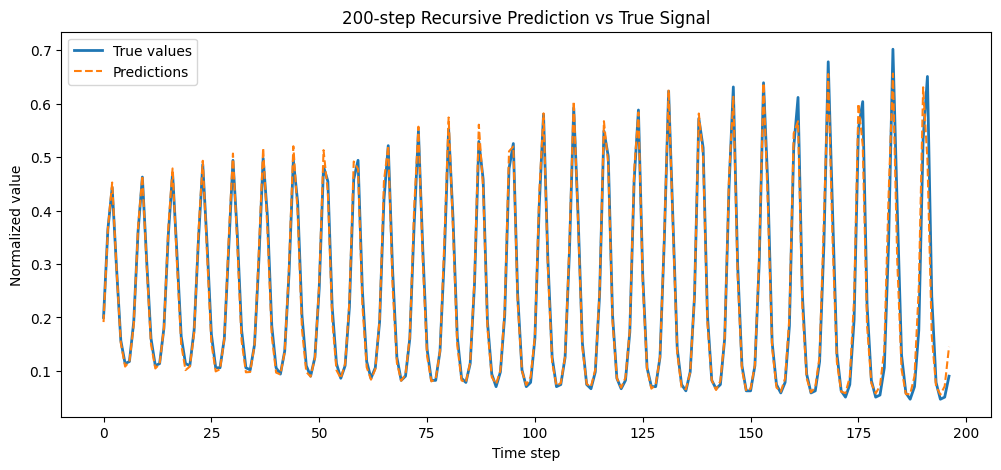

In [20]:
#-------------------------------------------------
# 200-step evaluation
#-------------------------------------------------
start_idx = split
start_window = series_full[start_idx:start_idx+window_size]

# determine max possible steps
max_steps = len(series_full) - (start_idx + window_size)
steps = min(200, max_steps)

true_future = series_full[start_idx+window_size:start_idx+window_size+steps] # true values

# convert start window to tensor
start_tensor = torch.tensor(start_window.reshape(window_size, 1), dtype=torch.float32)

preds = ensemble_recursive_predict(models, start_tensor, steps) # predictions

mae_200 = mean_absolute_error(true_future, preds)
mse_200 = mean_squared_error(true_future, preds)

print(f"\n{steps}-step MAE: {mae_200:.4f}")
print(f"\n{steps}-step MSE: {mse_200:.4f}")

#-----------------------
# plot
#-----------------------
import matplotlib.pyplot as plt

# Create x-axis (time steps)
t = range(len(true_future))

plt.figure(figsize=(12, 5))

# True signal
plt.plot(t, true_future, label="True values", linewidth=2)

# Predicted signal
plt.plot(t, preds, label="Predictions", linestyle='--')

plt.title("200-step Recursive Prediction vs True Signal")
plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.legend()

In [49]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
No GPU
